In [13]:
import os
import pandas as pd

root_dir = 'dataset/images'
output_csv_path = 'dataset/dataset.csv'

data = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    if dirpath != root_dir:
        label = os.path.basename(dirpath)
        for filename in filenames:
            file_path_full = os.path.normpath(os.path.join(dirpath, filename))
            data.append({'file_path': file_path_full, 'label': label})

df = pd.DataFrame(data)

df.to_csv(output_csv_path, index=False)

In [2]:
import pandas as pd
df = pd.read_csv("dataset/dataset.csv")

In [3]:
df = df.sample(n=min(10000, len(df)), random_state=42).reset_index(drop=True)
print(f"Dataset reduced to {len(df)} images")

Dataset reduced to 10000 images


In [3]:
df.head()

,file_path,label
0,"dataset/images/Tomato,Leaf Mold/plant_33685.jpg","Tomato,Leaf Mold"
1,"dataset/images/Tomato,Septoria Leaf Spot/plant...","Tomato,Septoria Leaf Spot"
2,"dataset/images/Apple,Healthy/plant_94196.jpg","Apple,Healthy"
3,"dataset/images/Apple,Alternaria Blotch/plant_7...","Apple,Alternaria Blotch"
4,"dataset/images/Apple,Healthy/plant_90707.jpg","Apple,Healthy"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  10000 non-null  object
 1   label      10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


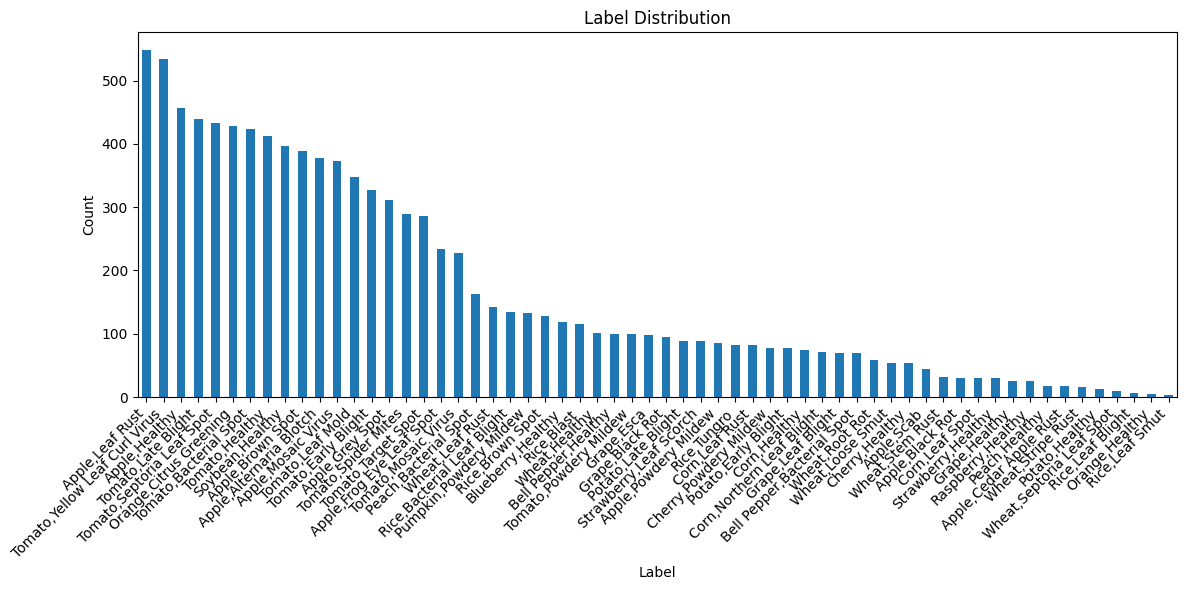

In [5]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()
plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
unique_labels = sorted(df['label'].unique())
class_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_class = {i: label for label, i in class_to_id.items()}
df['class_id'] = df['label'].map(class_to_id)

In [5]:
len(unique_labels)

60

In [8]:
df.sample(5)

,file_path,label,class_id
3953,"dataset/images/Tomato,Early Blight/plant_21796...","Tomato,Early Blight",43
5208,"dataset/images/Tomato,Healthy/plant_23974.jpg","Tomato,Healthy",44
4889,"dataset/images/Tomato,Mosaic Virus/plant_39989...","Tomato,Mosaic Virus",47
1398,"dataset/images/Tomato,Healthy/plant_26607.jpg","Tomato,Healthy",44
9393,"dataset/images/Tomato,Bacterial Spot/plant_177...","Tomato,Bacterial Spot",42


In [6]:
from sklearn.model_selection import train_test_split
X = df[['file_path', 'label']]
y = df['class_id']
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, test_size=(0.15/0.90), random_state=42, stratify=y_rem)

In [7]:
X_train.shape, X_val.shape, X_test.shape

((7500, 2), (1500, 2), (1000, 2))

In [8]:
import torch
from transformers import (
    ConvNextForImageClassification, 
    ConvNextImageProcessor, 
    TrainingArguments, 
    Trainer
)
import numpy as np
import evaluate

MODEL_CHECKPOINT = 'facebook/convnext-tiny-224'

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = ConvNextForImageClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(unique_labels),
    id2label=id_to_class,
    label2id=class_to_id,
    ignore_mismatched_sizes=True 
).to(device)

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of ConvNextForImageClassification were not initialized from the model checkpoint at facebook/convnext-tiny-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([60, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([60]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="weighted")

In [10]:
training_args = TrainingArguments(
    output_dir="./convnext_crop",
    num_train_epochs=15,                      
    per_device_train_batch_size=16,           
    per_device_eval_batch_size=32,            
    warmup_steps=500,                         
    weight_decay=0.01,                        
    logging_dir='./logs',
    logging_steps=250,
    save_strategy="epoch",  
    eval_strategy="epoch",                  
    load_best_model_at_end=True,              
    metric_for_best_model="f1",               
    learning_rate=2e-5,                       
    fp16=False,                               
)

In [11]:
processor = ConvNextImageProcessor.from_pretrained(MODEL_CHECKPOINT)

In [12]:
from datasets import Dataset
from PIL import Image
import torch

train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
val_df = pd.concat([X_val, y_val], axis=1).reset_index(drop=True)
test_df = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

def preprocess_images(examples):
    images = [Image.open(path).convert("RGB") for path in examples['file_path']]
    inputs = processor(images=images, return_tensors=None)
    inputs['labels'] = examples['class_id']
    return inputs

train_dataset = train_dataset.map(
    preprocess_images, 
    batched=True, 
    batch_size=32,  # Smaller batch size
    remove_columns=['file_path', 'label', 'class_id']
)
val_dataset = val_dataset.map(
    preprocess_images, 
    batched=True, 
    batch_size=32,
    remove_columns=['file_path', 'label', 'class_id']
)
test_dataset = test_dataset.map(
    preprocess_images, 
    batched=True, 
    batch_size=32,
    remove_columns=['file_path', 'label', 'class_id']
)

train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

Map: 100%|██████████| 1000/1000 [00:01<00:00, 607.76 examples/s]


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=processor,
    compute_metrics=compute_metrics,
)

In [14]:
trainer.train()

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1
1,3.988500,3.009565,0.294341
2,2.421100,1.585727,0.663557
3,1.220800,0.973992,0.816443
4,0.723300,0.690619,0.852985
5,0.480300,0.530291,0.877357
6,0.337700,0.450022,0.889427
7,0.246400,0.386908,0.898235
8,0.179400,0.353815,0.908359
9,0.148100,0.323394,0.911127
10,0.119400,0.302303,0.919373


/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.war

TrainOutput(global_step=7035, training_loss=0.6450733371550256, metrics={'train_runtime': 6323.2872, 'train_samples_per_second': 17.791, 'train_steps_per_second': 1.113, 'total_flos': 2.8313911729152e+18, 'train_loss': 0.6450733371550256, 'epoch': 15.0})

In [15]:
results = trainer.evaluate(test_dataset)
results

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.22988149523735046,
 'eval_f1': 0.9396787899000698,
 'eval_runtime': 11.0893,
 'eval_samples_per_second': 90.177,
 'eval_steps_per_second': 2.886,
 'epoch': 15.0}

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print(
    classification_report(
      y_true,
      y_pred,
      labels=list(range(len(unique_labels))), 
      target_names=unique_labels,
      zero_division=0
    )
)

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


                               precision    recall  f1-score   support

      Apple,Alternaria Blotch       0.93      0.97      0.95        38
              Apple,Black Rot       1.00      1.00      1.00         3
             Apple,Brown Spot       1.00      0.97      0.99        39
       Apple,Cedar Apple Rust       1.00      0.50      0.67         2
     Apple,Frog Eye Leaf Spot       0.96      1.00      0.98        23
              Apple,Grey Spot       0.87      0.87      0.87        31
                Apple,Healthy       0.92      1.00      0.96        46
              Apple,Leaf Rust       0.93      0.93      0.93        55
           Apple,Mosaic Virus       0.97      0.97      0.97        37
         Apple,Powdery Mildew       1.00      0.62      0.77         8
                   Apple,Scab       1.00      1.00      1.00         5
   Bell Pepper,Bacterial Spot       1.00      1.00      1.00         7
          Bell Pepper,Healthy       1.00      1.00      1.00        10
     

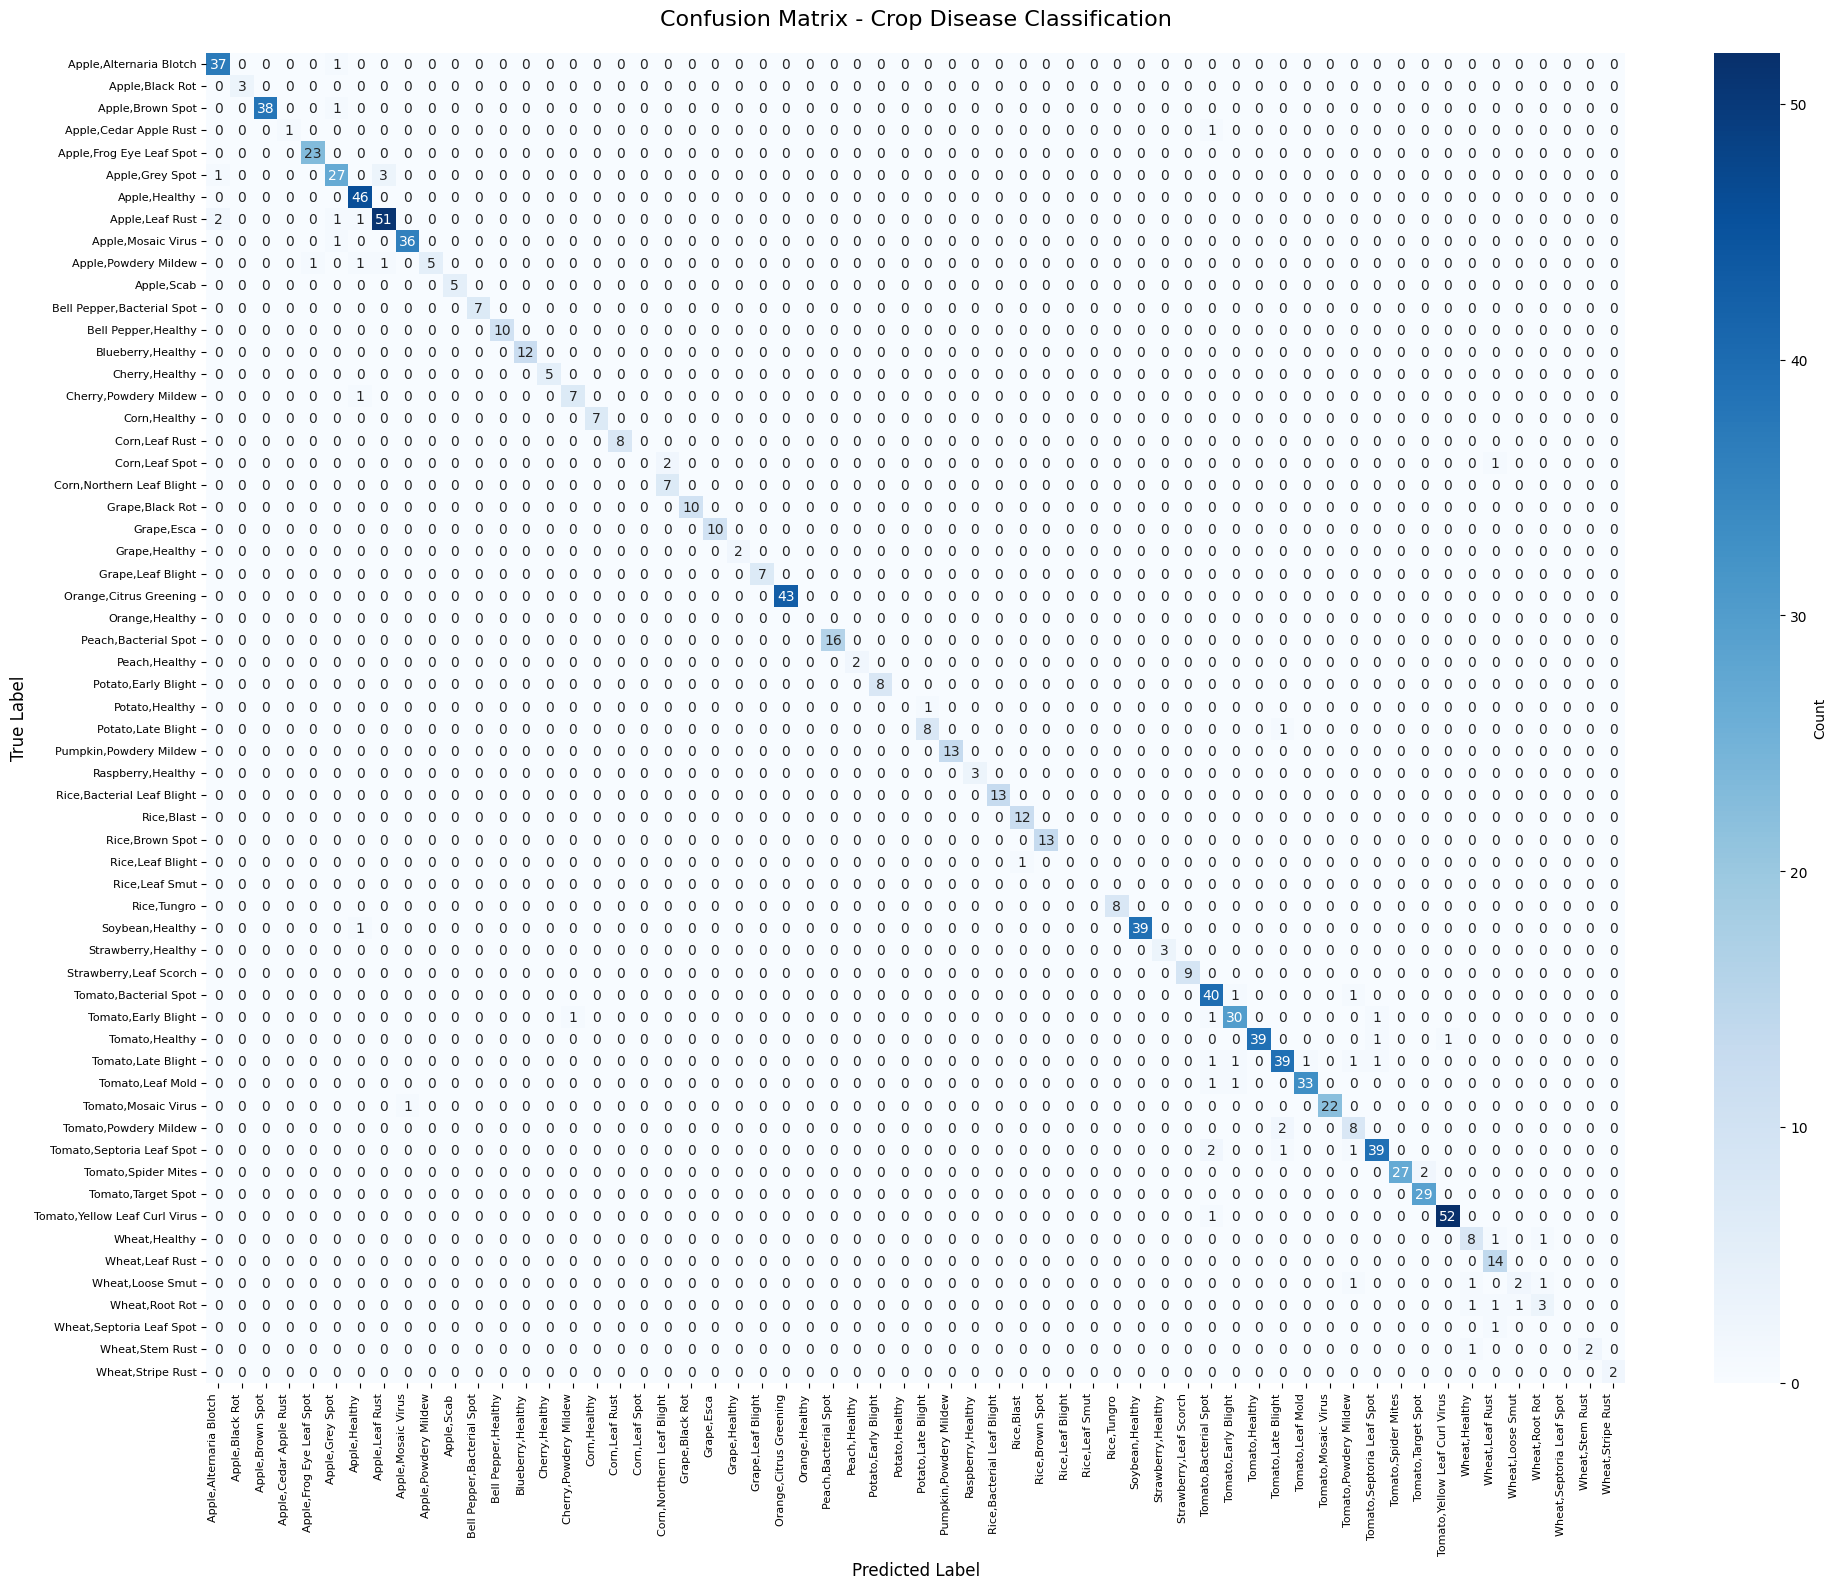

In [17]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(unique_labels))))

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Crop Disease Classification', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()